In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model20_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model20_0)
describe(model20_0)

MACs: 4.1 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-7               [1, 30, 16, 16]           --
│    │    └─PReLU: 3-8                   [1, 30, 16, 16]           1
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 1

Loading checkpoint from model_weights/model20_0.pt
Starting
Epoch 1/60: Train loss = 1.1248, Train accuracy = 0.5990, Test loss = 1.1203, Test accuracy = 0.6059
Epoch 2/60: Train loss = 0.9040, Train accuracy = 0.6810, Test loss = 0.9047, Test accuracy = 0.6804
Epoch 3/60: Train loss = 0.8083, Train accuracy = 0.7147, Test loss = 0.7993, Test accuracy = 0.7225
Epoch 4/60: Train loss = 0.7331, Train accuracy = 0.7414, Test loss = 0.7478, Test accuracy = 0.7404
Epoch 5/60: Train loss = 0.7493, Train accuracy = 0.7422, Test loss = 0.8261, Test accuracy = 0.7249
Epoch 6/60: Train loss = 0.7455, Train accuracy = 0.7417, Test loss = 0.7882, Test accuracy = 0.7309
Epoch 7/60: Train loss = 0.7412, Train accuracy = 0.7436, Test loss = 0.7973, Test accuracy = 0.7318
Epoch 8/60: Train loss = 0.6210, Train accuracy = 0.7841, Test loss = 0.6444, Test accuracy = 0.7811
Epoch 9/60: Train loss = 0.6664, Train accuracy = 0.7697, Test loss = 0.6993, Test accuracy = 0.7663
Epoch 10/60: Train loss = 0.548

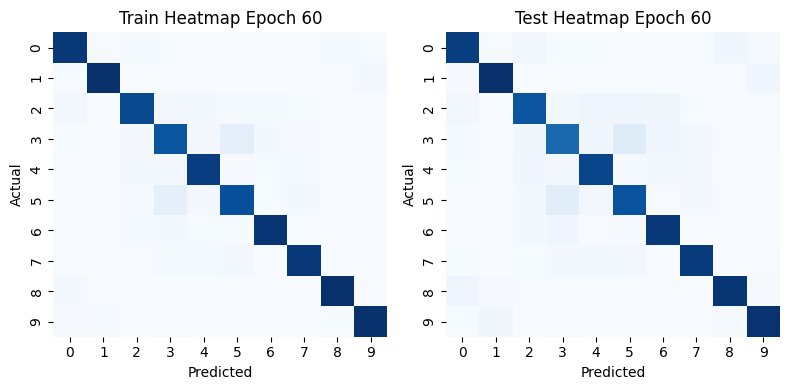

<Figure size 1200x600 with 0 Axes>

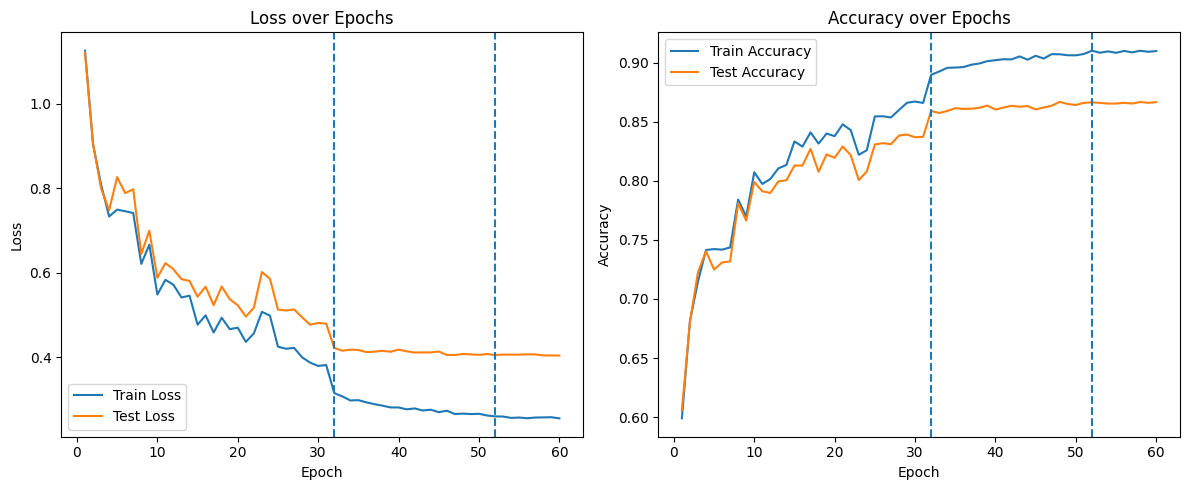

In [6]:
trainf32(model20_0,"model_weights/model20_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model20_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model20_1)
describe(model20_1)

MACs: 4.1 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-7               [1, 30, 16, 16]           --
│    │    └─PReLU: 3-8                   [1, 30, 16, 16]           1
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 1

Loading checkpoint from model_weights/model20_1.pt
Starting
Epoch 1/60: Train loss = 1.0267, Train accuracy = 0.6401, Test loss = 1.0208, Test accuracy = 0.6425
Epoch 2/60: Train loss = 0.9061, Train accuracy = 0.6765, Test loss = 0.9033, Test accuracy = 0.6847
Epoch 3/60: Train loss = 0.8378, Train accuracy = 0.7068, Test loss = 0.8742, Test accuracy = 0.7004
Epoch 4/60: Train loss = 0.8624, Train accuracy = 0.7160, Test loss = 0.9240, Test accuracy = 0.7075
Epoch 5/60: Train loss = 0.7258, Train accuracy = 0.7477, Test loss = 0.7798, Test accuracy = 0.7382
Epoch 6/60: Train loss = 0.6038, Train accuracy = 0.7904, Test loss = 0.6360, Test accuracy = 0.7795
Epoch 7/60: Train loss = 0.5857, Train accuracy = 0.7950, Test loss = 0.6200, Test accuracy = 0.7889
Epoch 8/60: Train loss = 0.5773, Train accuracy = 0.8005, Test loss = 0.6133, Test accuracy = 0.7924
Epoch 9/60: Train loss = 0.5676, Train accuracy = 0.8018, Test loss = 0.5925, Test accuracy = 0.7931
Epoch 10/60: Train loss = 0.619

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 35/60: Train loss = 0.2913, Train accuracy = 0.8981, Test loss = 0.4127, Test accuracy = 0.8618
Epoch 36/60: Train loss = 0.2870, Train accuracy = 0.8996, Test loss = 0.4043, Test accuracy = 0.8623
Epoch 37/60: Train loss = 0.2855, Train accuracy = 0.8992, Test loss = 0.4053, Test accuracy = 0.8647
Epoch 38/60: Train loss = 0.2822, Train accuracy = 0.9012, Test loss = 0.4025, Test accuracy = 0.8637
Epoch 39/60: Train loss = 0.2840, Train accuracy = 0.9001, Test loss = 0.4028, Test accuracy = 0.8638
Epoch 40/60: Train loss = 0.2790, Train accuracy = 0.9017, Test loss = 0.4045, Test accuracy = 0.8639
Epoch 41/60: Train loss = 0.2796, Train accuracy = 0.9012, Test loss = 0.4043, Test accuracy = 0.8668
Epoch 42/60: Train loss = 0.2734, Train accuracy = 0.9024, Test loss = 0.4029, Test accuracy = 0.8662
Epoch 43/60: Train loss = 0.2750, Train accuracy = 0.9046, Test loss = 0.4069, Test accuracy = 0.8623
Epoch 44/60: Train loss = 0.2705, Train accuracy = 0.9049, Test loss = 0.4121, Tes

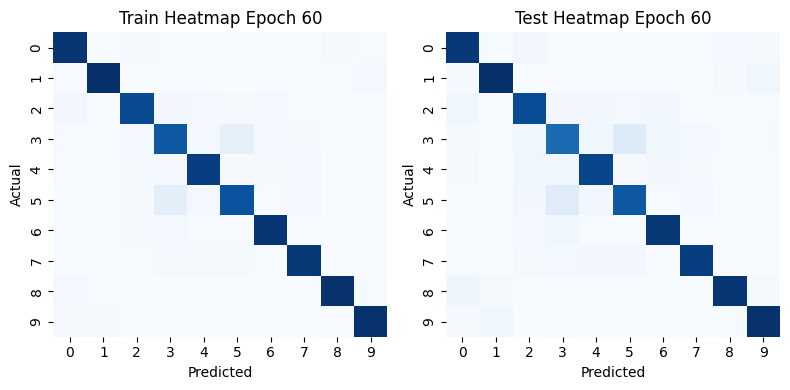

<Figure size 1200x600 with 0 Axes>

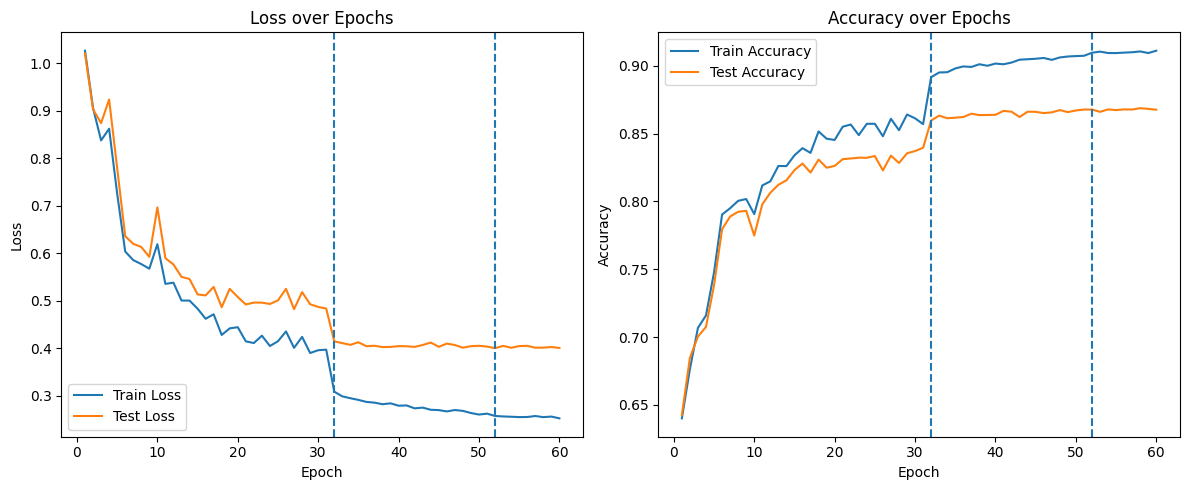

In [8]:
trainf32(model20_1,"model_weights/model20_1.pt",criterion,train_dataset,val_dataset, batch_size=64)